## 📦 Importing Libraries

In this step, we import the necessary Python libraries required for data analysis.


In [28]:
# Import 
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Data Loading

In this step, the dataset is loaded into a pandas DataFrame.

A DataFrame is a tabular data structure (similar to Excel) that allows us to manipulate and analyze data efficiently.

Loading the data is the first step before performing any analysis.


In [29]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv("../data/online_retail.csv")

## 👀 Data Preview

We display the first few rows of the dataset to understand its structure, column names, and the type of data it contains.


In [30]:
# Display the first 5 rows to understand the dataset structure
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 🧐 Data Understanding

Before performing any analysis, it is important to understand the structure and quality of the dataset.

In this step, we will:

- Examine the size of the dataset
- Review column names and data types
- Generate summary statistics
- Identify missing values and potential anomalies


In [31]:
# Check number of rows and columns
data.shape

(541909, 8)

In [32]:
# Get column info and data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [33]:
# Get descriptive statistics for numeric columns
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 📊 Outlier Visualization

A scatter plot is used to visualize the relationship between Quantity and UnitPrice.

This helps identify extreme values and detect outliers visually.


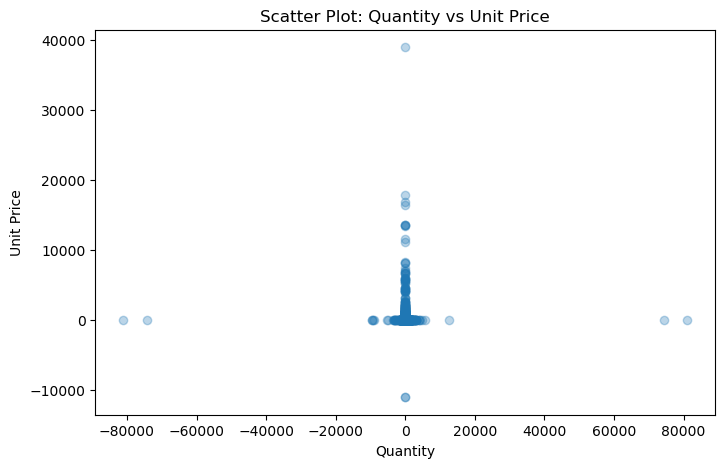

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(data['Quantity'], data['UnitPrice'], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Scatter Plot: Quantity vs Unit Price")
plt.show()

In [35]:
# Count missing values per column
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 🔍 Key Observations

From the initial exploration of the dataset:

- The dataset contains a large number of transactions.
- Missing values exist in the `Description` and `CustomerID` columns.
- Negative values are present in `Quantity` and `UnitPrice`, likely representing product returns or data errors.
- Significant outliers exist in both quantity and pricing data.
- Certain columns may require type conversion (InvoiceDate).

These issues will be addressed during the data cleaning phase.


## 🧹 Data Cleaning

Before performing analysis, it is essential to clean the dataset to ensure accuracy and consistency.

In this step, we will:

- Handle missing values
- Remove invalid or irrelevant data
- Convert data types where necessary
- Create new features for analysis


## 👤 Handling Missing Customer IDs

Instead of removing rows with missing CustomerID values, we retain all transactions to preserve total revenue.

Missing CustomerID values are replaced with a placeholder label ("Unknown") to indicate unidentified customers.


In [36]:
# Replace missing BEFORE converting (BEST way)
data['CustomerID'] = data['CustomerID'].fillna(0).astype(int)

In [37]:
# Keep only positive quantities
data = data[data['Quantity'] > 0]

# Keep only positive prices
data = data[data['UnitPrice'] > 0]

In [38]:
# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

## 🚨 Outlier Handling

Extreme values were identified in Quantity and UnitPrice.

These values are significantly higher than the normal range and can distort analysis.

Outliers were removed to ensure more reliable and realistic insights.


## 🔍 Identifying Extreme Values

To understand potential anomalies in the dataset, we first examine the maximum values of key numerical variables such as Quantity and UnitPrice.

This helps identify unusually large transactions that may require further investigation.


In [39]:
# Check maximum values
data[['Quantity', 'UnitPrice']].max()

Quantity     80995.00
UnitPrice    13541.33
dtype: float64

## 🔎 Investigating Extreme Transactions

After identifying extreme values, we locate the specific transactions responsible for these values.

This helps us understand whether these are valid business transactions or anomalies.


In [40]:
# Find rows with max Quantity
data[data['Quantity'] == data['Quantity'].max()]

# Find rows with max UnitPrice
data[data['UnitPrice'] == data['UnitPrice'].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,0,United Kingdom


## 🧠 Understanding the Nature of Extreme Values

We now examine the details of these transactions, including Description, StockCode, and Quantity, to determine their nature.


In [41]:
# Display relevant columns
data[data['UnitPrice'] == data['UnitPrice'].max()][
    ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33


## 🔍 Investigating High Unit Prices

To better understand unusually high values, we filter transactions where UnitPrice exceeds a certain threshold.

We start with a threshold of 20 to identify potentially abnormal or non-standard entries.


In [42]:
# Select high value transactions
high_values = data[data['UnitPrice'] > 20]

# Count descriptions
high_values['Description'].value_counts().head(20)

Description
DOTCOM POSTAGE                      691
POSTAGE                             250
REGENCY CAKESTAND 3 TIER            247
PICNIC BASKET WICKER LARGE          186
SET/4 WHITE RETRO STORAGE CUBES     155
CARRIAGE                            139
ENAMEL BREAD BIN CREAM              120
RED RETROSPOT CAKE STAND             97
Manual                               87
RED RETROSPOT ROUND CAKE TINS        85
BOTANICAL GARDENS WALL CLOCK         83
CREAM SWEETHEART MINI CHEST          71
VICTORIAN SEWING BOX LARGE           61
WOODEN CROQUET GARDEN SET            56
3 TIER CAKE TIN GREEN AND CREAM      54
SET 3 WICKER STORAGE BASKETS         47
3 TIER SWEETHEART GARDEN SHELF       43
LOVE SEAT ANTIQUE WHITE METAL        41
SET OF 2 WOODEN MARKET CRATES        40
VINTAGE RED KITCHEN CABINET          38
Name: count, dtype: int64

In [43]:
# List of non-product keywords
non_products = ['POSTAGE', 'MANUAL', 'DISCOUNT', 'AMAZON', 'DOTCOM', 'BANK CHARGES', 'CARRIAGE', 'SAMPLE', 'TEST', 'RETURN', 'CHARGE', 'FEE', 'Adjust bad debt']

# Remove them
data = data[~data['Description'].str.contains('|'.join(non_products), case=False, na=False)]

In [44]:
# Select high value transactions
high_values = data[data['UnitPrice'] > 20]

# Count descriptions
high_values['Description'].value_counts().head(20)

Description
REGENCY CAKESTAND 3 TIER            247
PICNIC BASKET WICKER LARGE          186
SET/4 WHITE RETRO STORAGE CUBES     155
ENAMEL BREAD BIN CREAM              120
RED RETROSPOT CAKE STAND             97
RED RETROSPOT ROUND CAKE TINS        85
BOTANICAL GARDENS WALL CLOCK         83
CREAM SWEETHEART MINI CHEST          71
VICTORIAN SEWING BOX LARGE           61
WOODEN CROQUET GARDEN SET            56
3 TIER CAKE TIN GREEN AND CREAM      54
SET 3 WICKER STORAGE BASKETS         47
3 TIER SWEETHEART GARDEN SHELF       43
LOVE SEAT ANTIQUE WHITE METAL        41
SET OF 2 WOODEN MARKET CRATES        40
VINTAGE RED KITCHEN CABINET          38
12 EGG HOUSE PAINTED WOOD            36
BOX OF VINTAGE ALPHABET BLOCKS       33
IVORY EMBROIDERED QUILT              31
CABIN BAG VINTAGE RETROSPOT          31
Name: count, dtype: int64

High-value transactions were analyzed to identify recurring non-product entries such as shipping fees, manual adjustments, and platform-related charges (e.g., Amazon fees). These were excluded based on their business nature rather than purely numerical thresholds.


In [45]:
data[data['UnitPrice'] > 700]['Description'].value_counts().head(25)

Series([], Name: count, dtype: int64)

In [46]:
# Remove extreme UnitPrice values
data = data[data['UnitPrice'] < 700]

In [47]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,524069.000000,524069,524069.000000,524069.000000
mean,10.573825,2011-07-05 00:56:58.060789,3.257411,11488.510412
min,1.000000,2010-12-01 08:26:00,0.001000,0.000000
25%,1.000000,2011-03-28 12:49:00,1.250000,12354.000000
50%,3.000000,2011-07-20 14:55:00,2.080000,14396.000000
75%,11.000000,2011-10-19 14:40:00,4.130000,16278.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,156.354123,NaN,4.381066,6783.180291


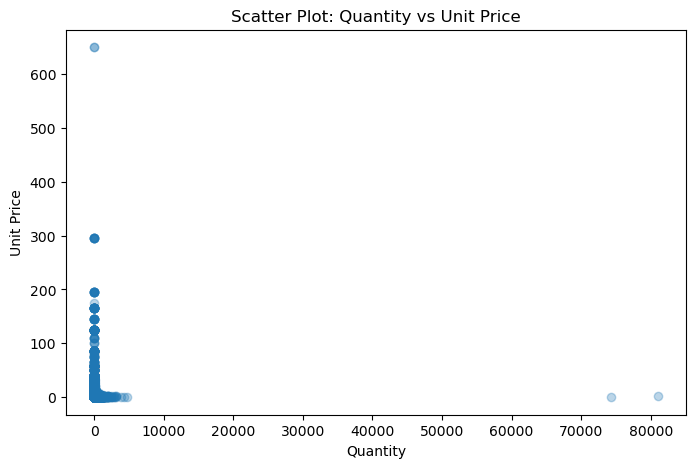

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(data['Quantity'], data['UnitPrice'], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Scatter Plot: Quantity vs Unit Price")
plt.show()

## 📊 Outlier Analysis

After removing extreme outliers, the data shows a clear and realistic distribution.

- Most transactions involve low quantities and low unit prices
- Some higher-value transactions remain, representing bulk purchases or premium products

The dataset is now clean and suitable for reliable analysis.


In [49]:
# Create Revenue column
data['Revenue'] = data['Quantity'] * data['UnitPrice']

In [50]:
# Display the first 5 rows of the cleaned dataset
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [51]:
# Get descriptive statistics for the cleaned dataset
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,524069.000000,524069,524069.000000,524069.000000,524069.000000
mean,10.573825,2011-07-05 00:56:58.060789,3.257411,11488.510412,19.424068
min,1.000000,2010-12-01 08:26:00,0.001000,0.000000,0.001000
25%,1.000000,2011-03-28 12:49:00,1.250000,12354.000000,3.750000
50%,3.000000,2011-07-20 14:55:00,2.080000,14396.000000,9.900000
75%,11.000000,2011-10-19 14:40:00,4.130000,16278.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000,168469.600000
std,156.354123,NaN,4.381066,6783.180291,269.326674


In [52]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

## 🔧 Data Type Standardization

Before exporting the dataset, we ensure that all columns have the correct data types.

This prevents errors in Power BI and ensures accurate calculations.


In [53]:
# ----------------------------
# FIX DATA TYPES
# ----------------------------

# Convert numeric columns
data['Quantity'] = pd.to_numeric(data['Quantity'], errors='coerce')
data['UnitPrice'] = pd.to_numeric(data['UnitPrice'], errors='coerce')

# Revenue (recalculate to be safe)
data['Revenue'] = data['Quantity'] * data['UnitPrice']
data['Revenue'] = pd.to_numeric(data['Revenue'], errors='coerce')

# CustomerID as string (important for Power BI counting)
data['CustomerID'] = data['CustomerID'].astype(str)

# InvoiceNo as string
data['InvoiceNo'] = data['InvoiceNo'].astype(str)

# Description as string
data['Description'] = data['Description'].astype(str)

# Country as string
data['Country'] = data['Country'].astype(str)

# Convert date properly
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')

# ----------------------------
# REMOVE ANY BROKEN ROWS
# ----------------------------

data = data.dropna(subset=['Quantity', 'UnitPrice', 'Revenue', 'InvoiceDate'])

# ----------------------------
# FINAL CHECK
# ----------------------------

print(data.dtypes)

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
Revenue               float64
dtype: object


In [54]:
data.to_csv("../data/online_retail_cleaned.csv", index=False, sep=';', decimal=',')

## Data Cleaning Summary

The dataset was cleaned by:

- Removing rows with missing CustomerID values
- Filtering out negative quantities and prices
- Converting InvoiceDate to datetime format
- Creating a Revenue column for analysis

The dataset is now ready for accurate and meaningful analysis.
